
TFG

Este es el codigo del tfg de Borja Jimeno

In [6]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos

import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm

import re

path="/home/borja/Documents/TFG/GeneraRitmo/Libs/ANAIS"
sys.path.append(path)

from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

plt.rcParams['font.size'] = 18

In [7]:
import numpy as np


def carga_datos_hist(titulo,archivo):
    file = uproot.open(archivo)
    file.keys()

    graph = file[titulo]
    aux=graph.member("fX")

    longitud=len(aux)
    datos=np.zeros((2,longitud))

    
    
    datos[0]=graph.member("fX")
    datos[1]=graph.member("fY")
    
    return datos


Datos_DM_16_p=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SDproton","SD_16.root")
Datos_WI_16_p=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_WI_SDproton","SD_16.root")

DM_16_p=Datos_DM_16_p[1]
WI_16_p=Datos_WI_16_p[1]

DM_16_p_m=Datos_DM_16_p[0]
WI_16_p_m=Datos_WI_16_p[0]


Datos_DM_16_n=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SDneutron","SD_16.root")
Datos_WI_16_n=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_WI_SDneutron","SD_16.root")

DM_16_n=Datos_DM_16_n[1]
WI_16_n=Datos_WI_16_n[1]

DM_16_n_m=Datos_DM_16_n[0]
WI_16_n_m=Datos_WI_16_n[0]



In [8]:
def elimina_sing(array_d,array_m):
    aa=0
    while(aa==0):
        if (array_d[0]<0 or array_d[0]>1):
            array_d=np.delete(array_d,0)
            array_m=np.delete(array_m,0)
        else:
            aa=1
    return array_d,array_m

DM_16_p, DM_16_p_m = elimina_sing(DM_16_p,DM_16_p_m)
DM_16_n, DM_16_n_m = elimina_sing(DM_16_n,DM_16_n_m)

WI_16_p, WI_16_p_m = elimina_sing(WI_16_p,WI_16_p_m)
WI_16_n, WI_16_n_m = elimina_sing(WI_16_n,WI_16_n_m)

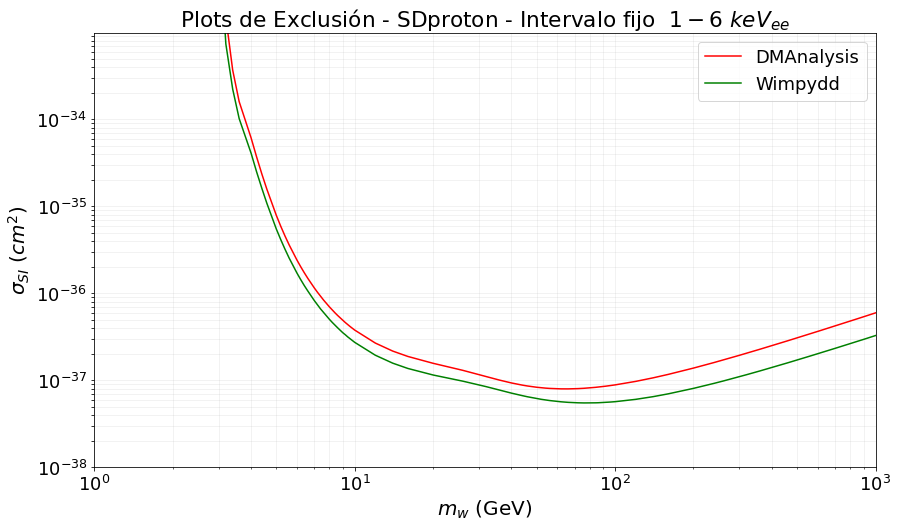

In [9]:
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes


ax.plot(DM_16_p_m,DM_16_p, linestyle='-',label="DMAnalysis", alpha=1,c="red")
ax.plot(WI_16_p_m,WI_16_p, linestyle='-', label="Wimpydd", alpha=1,c="green")

ax.legend()

ax.set_title(r'Plots de Exclusión - SDproton - Intervalo fijo  $1-6$ $keV_{ee}$')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-33
y_inf=1e-38

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)



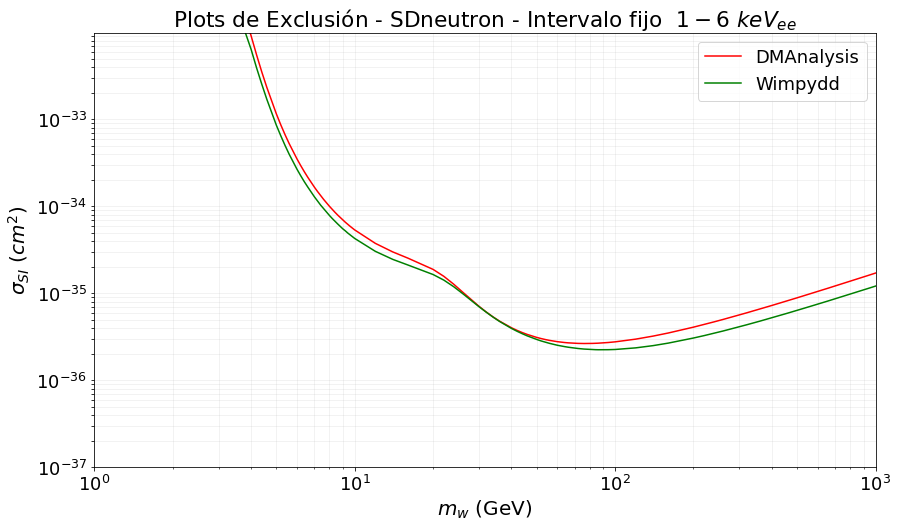

In [10]:
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes


ax.plot(DM_16_n_m,DM_16_n, linestyle='-',label="DMAnalysis", alpha=1,c="red")
ax.plot(WI_16_n_m,WI_16_n, linestyle='-', label="Wimpydd", alpha=1,c="green")

ax.legend()

ax.set_title(r'Plots de Exclusión - SDneutron - Intervalo fijo  $1-6$ $keV_{ee}$')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")


y_sup=1e-32
y_inf=1e-37


ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

